In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import random
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, Concatenate, LeakyReLU, ConvLSTM2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

2025-07-11 06:21:09.103251: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752214869.304500      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752214869.369793      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
csv_path = "/kaggle/input/nuero-dataset-balanced/nuero_dataset_balanced/image_labels_balanced.csv"
images_path = "/kaggle/input/nuero-dataset-balanced/nuero_dataset_balanced/images"
model_path = 'final_mobilenet_model.keras'
label_encoder_path = 'label_encoder_classes.npy'

Number of Images
COVID: 1000
Lung_Opacity: 1000
Viral_Pneumonia: 1000
Glioma: 1000
Pituitary: 930
Meningioma: 708
esophagitis: 500
polyps: 500
ulcerative-colitis: 500


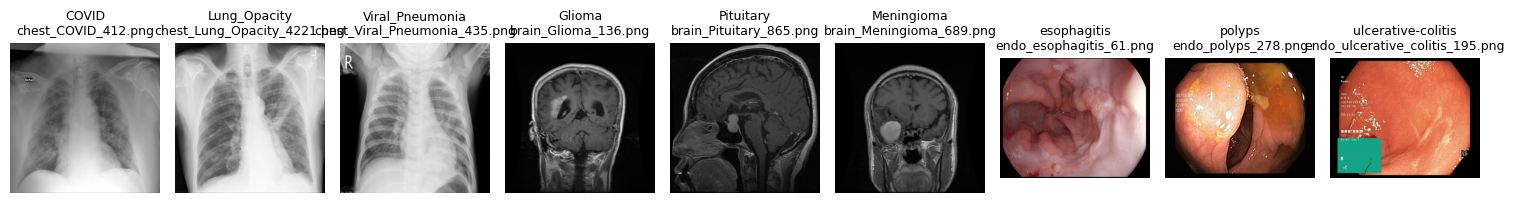

In [3]:
df = pd.read_csv(csv_path)
class_counts = df['label'].value_counts()
classes = class_counts.index

print("Number of Images")
for class_name in classes:
    print(f"{class_name}: {class_counts[class_name]}")

plt.figure(figsize=(15, 4))
for idx, class_name in enumerate(classes):
    class_files = df[df['label'] == class_name]['filename'].tolist()
    sample_file = random.choice(class_files)
    image_path = os.path.join(images_path, sample_file)
    img = Image.open(image_path)
    
    plt.subplot(1, len(classes), idx + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{class_name}\n{sample_file}", fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])
num_classes = len(label_encoder.classes_)

train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    # horizontal_flip=True,             # Safe for X-rays and MRIs (not for endoscopy)
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=images_path,
    x_col='filename',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=images_path,
    x_col='filename',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 5710 validated image filenames belonging to 9 classes.
Found 1428 validated image filenames belonging to 9 classes.


In [5]:
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

truncated_output = base_model.get_layer(truncate_layer).output
truncated_model = Model(inputs=base_model.input, outputs=truncated_output)

truncated_model.trainable = False

def modified_inception_block(x):
    branch1 = Conv2D(64, (1, 1), padding='same')(x)
    branch1 = LeakyReLU(alpha=0.1)(branch1)

    branch2 = Conv2D(96, (1, 1), padding='same')(x)
    branch2 = LeakyReLU(alpha=0.1)(branch2)
    branch2 = Conv2D(128, (3, 3), padding='same')(branch2)
    branch2 = LeakyReLU(alpha=0.1)(branch2)

    branch3 = Conv2D(32, (1, 1), padding='same')(x)
    branch3 = LeakyReLU(alpha=0.1)(branch3)
    branch3 = Conv2D(64, (5, 5), padding='same')(branch3)
    branch3 = LeakyReLU(alpha=0.1)(branch3)

    branch4 = Conv2D(32, (1, 1), padding='same')(x)
    branch4 = LeakyReLU(alpha=0.1)(branch4)
    branch4 = Conv2D(64, (7, 7), padding='same')(branch4)
    branch4 = LeakyReLU(alpha=0.1)(branch4)

    branch5 = Conv2D(16, (1, 1), padding='same')(x)
    branch5 = LeakyReLU(alpha=0.1)(branch5)
    branch5 = Conv2D(32, (11, 11), padding='same')(branch5)
    branch5 = LeakyReLU(alpha=0.1)(branch5)

    branch6 = tf.keras.layers.MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    branch6 = Conv2D(64, (1, 1), padding='same')(branch6)
    branch6 = LeakyReLU(alpha=0.1)(branch6)

    output = Concatenate()([branch1, branch2, branch3, branch4, branch5, branch6])
    return output

inputs = truncated_model.input
x = modified_inception_block(truncated_model.output)
x = tf.keras.layers.Reshape((1, x.shape[1], x.shape[2], x.shape[3]))(x)  #time dimension for ConvLSTM
x = ConvLSTM2D(filters=64, kernel_size=(3, 3), padding='same', return_sequences=False)(x)
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_mobilenet_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

model.summary()
total_params = model.count_params()
print(f"Total number of parameters in the model: {total_params:,}")

I0000 00:00:1752214904.159763      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 32)   │            128 │ conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_1                 │ (None, 112, 112, 32)   │            288 │ conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_1_bn              │ (None, 112, 112, 32)   │            128 │ conv_dw_1[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_1_relu (ReLU)     │ (None, 112, 112, 32)   │              0 │ conv_dw_1_bn[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_1 (Conv2D)        │ (None, 112, 112, 64)   │          2,048 │ conv_dw_1_relu[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_1_bn              │ (None, 112, 112, 64)   │            256 │ conv_pw_1[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_1_relu (ReLU)     │ (None, 112, 112, 64)   │              0 │ conv_pw_1_bn[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pad_2                │ (None, 113, 113, 64)   │              0 │ conv_pw_1_relu[0][0]   │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_2                 │ (None, 56, 56, 64)     │            576 │ conv_pad_2[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_2_bn              │ (None, 56, 56, 64)     │            256 │ conv_dw_2[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_2_relu (ReLU)     │ (None, 56, 56, 64)     │              0 │ conv_dw_2_bn[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_2 (Conv2D)        │ (None, 56, 56, 128)    │          8,192 │ conv_dw_2_relu[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_2_bn              │ (None, 56, 56, 128)    │            512 │ conv_pw_2[0][0]        │
│ (BatchNormalization) 

 Total params: 3,275,289 (12.49 MB)

 Trainable params: 2,182,489 (8.33 MB)

 Non-trainable params: 1,092,800 (4.17 MB)

Total number of parameters in the model: 3,275,289


In [7]:
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[early_stopping, checkpoint, reduce_lr],
    verbose=1
)

model.save(model_path)
np.save(label_encoder_path, label_encoder.classes_)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1752214918.231243      96 service.cc:148] XLA service 0x7f0af4002e00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752214918.232089      96 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1752214919.328079      96 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/179 ━━━━━━━━━━━━━━━━━━━━ 53:56 18s/step - accuracy: 0.1250 - loss: 2.1728

I0000 00:00:1752214926.049624      96 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


179/179 ━━━━━━━━━━━━━━━━━━━━ 172s 867ms/step - accuracy: 0.3083 - loss: 1.6288 - val_accuracy: 0.6366 - val_loss: 0.6627 - learning_rate: 0.0010
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 100s 556ms/step - accuracy: 0.6113 - loss: 0.7235 - val_accuracy: 0.6884 - val_loss: 0.5962 - learning_rate: 0.0010
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 100s 557ms/step - accuracy: 0.6785 - loss: 0.6274 - val_accuracy: 0.6639 - val_loss: 0.7005 - learning_rate: 0.0010
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 101s 562ms/step - accuracy: 0.7457 - loss: 0.5416 - val_accuracy: 0.8053 - val_loss: 0.5120 - learning_rate: 0.0010
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 99s 552ms/step - accuracy: 0.7965 - loss: 0.4601 - val_accuracy: 0.7990 - val_loss: 0.4493 - learning_rate: 0.0010
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 101s 562ms/step - accuracy: 0.8426 - loss: 0.3911 - val_accuracy: 0.8515 - val_loss: 0.4462 - learning_rate: 0.0010
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 100s 557ms/step - accuracy: 0.8514 -

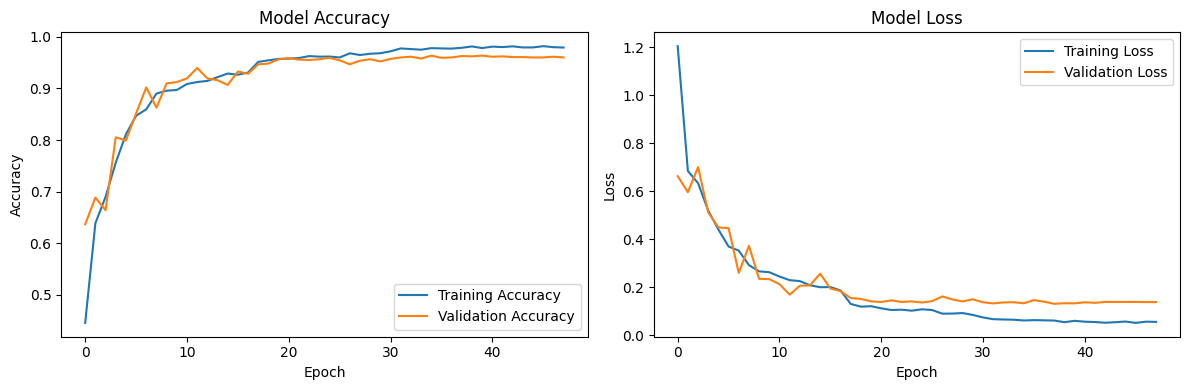

Found 1428 validated image filenames belonging to 9 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 219ms/step - accuracy: 0.9634 - loss: 0.1161
Test Loss: 0.1311
Test Accuracy: 0.9629
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 245ms/step


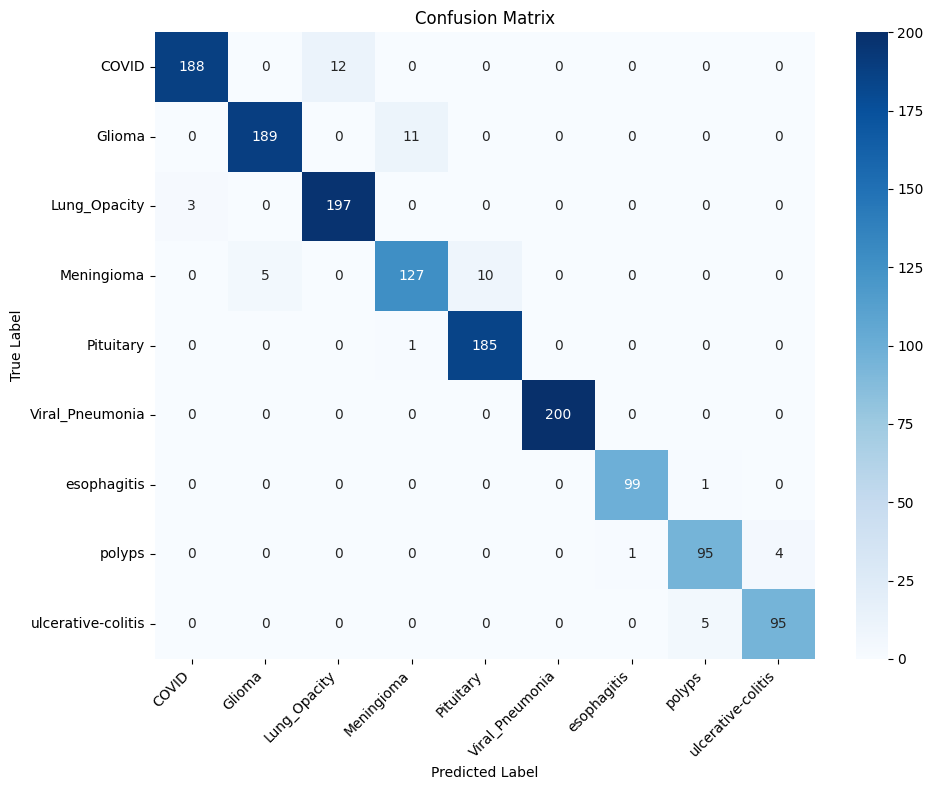


Classification Report:
                    precision    recall  f1-score   support

             COVID       0.98      0.94      0.96       200
            Glioma       0.97      0.94      0.96       200
      Lung_Opacity       0.94      0.98      0.96       200
        Meningioma       0.91      0.89      0.90       142
         Pituitary       0.95      0.99      0.97       186
   Viral_Pneumonia       1.00      1.00      1.00       200
       esophagitis       0.99      0.99      0.99       100
            polyps       0.94      0.95      0.95       100
ulcerative-colitis       0.96      0.95      0.95       100

          accuracy                           0.96      1428
         macro avg       0.96      0.96      0.96      1428
      weighted avg       0.96      0.96      0.96      1428



In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=images_path,
    x_col='filename',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

model = tf.keras.models.load_model(model_path)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=label_encoder.classes_))